In [2]:
#1 librerias
%matplotlib inline
import sklearn as sk
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.metrics import (accuracy_score,f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale,
)

In [3]:
#2 buscar datos 
# import pandas as pd
# df =pd.read_excel('indicador.xlsx')

iris = load_iris()
X = iris.data[:, :2]
y = iris.target
print(X.shape)

(150, 2)


In [4]:
#3 dividir conjuntos
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    random_state=42,
                                                    shuffle=True,
                                                    test_size=0.2,
                                                    stratify=y)



Una vez que se entrega el transformer no es hace necesario usar el fit en X_test hola mundo

In [6]:
#4 escalar datos 
sescaler= StandardScaler()
X_train_escalada=sescaler.fit_transform(X_train)
X_test_escalada=sescaler.fit_transform(X_test)

modelo1 = KNN(n_neighbors=5,
              weights="distance" por defecto none), distance se usa para hacer un DW KNN
metric=["manhattan","chebyshev","cosine","minkowski"] "minkowski" va con ,p= 3 o mas 2 es euclidiano y 1 manhattan

In [8]:
# 5 instanciar modelo
modelo = KNN(n_neighbors=5)
modelo1 = KNN(n_neighbors=5,weights=None,metric="minkowski",p=3)
# correr modelo se puede hacer junto classifier = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
clasificarKNN= modelo.fit(X_train_escalada,y_train)
clasificarKNN1= modelo1.fit(X_train_escalada,y_train)

In [9]:
# 6 score
print("Con train: {:.3f}".format(clasificarKNN.score(X_train_escalada,y_train)))
print('Con test: {:.3f}'.format( clasificarKNN.score(X_test_escalada,y_test)))
print("Con train1: {:.3f}".format(clasificarKNN1.score(X_train_escalada,y_train)))
print('Con test1: {:.3f}'.format( clasificarKNN1.score(X_test_escalada,y_test)))
# 8 accuracy


Con train: 0.867
Con test: 0.833
Con train1: 0.833
Con test1: 0.833


In [10]:
# 7 aaccuracy_score y f1_score
y_pre_log= clasificarKNN.predict(X_test_escalada)
print('Accuracy: {:.3f}'.format(accuracy_score(y_test, y_pre_log)))
print('f1score: {:.3f}'.format(f1_score(y_test, y_pre_log,average='weighted')))
y_pre_proba=clasificarKNN.predict_proba(X_test_escalada)
#####################################abs
print("###################################################")
y_pre_log1= clasificarKNN1.predict(X_test_escalada)
print('Accuracy1: {:.3f}'.format(accuracy_score(y_test, y_pre_log1)))
print('f1score1: {:.3f}'.format(f1_score(y_test, y_pre_log1,average='weighted')))
y_pre_proba=clasificarKNN1.predict_proba(X_test_escalada)

Accuracy: 0.833
f1score: 0.833
###################################################
Accuracy1: 0.833
f1score1: 0.833


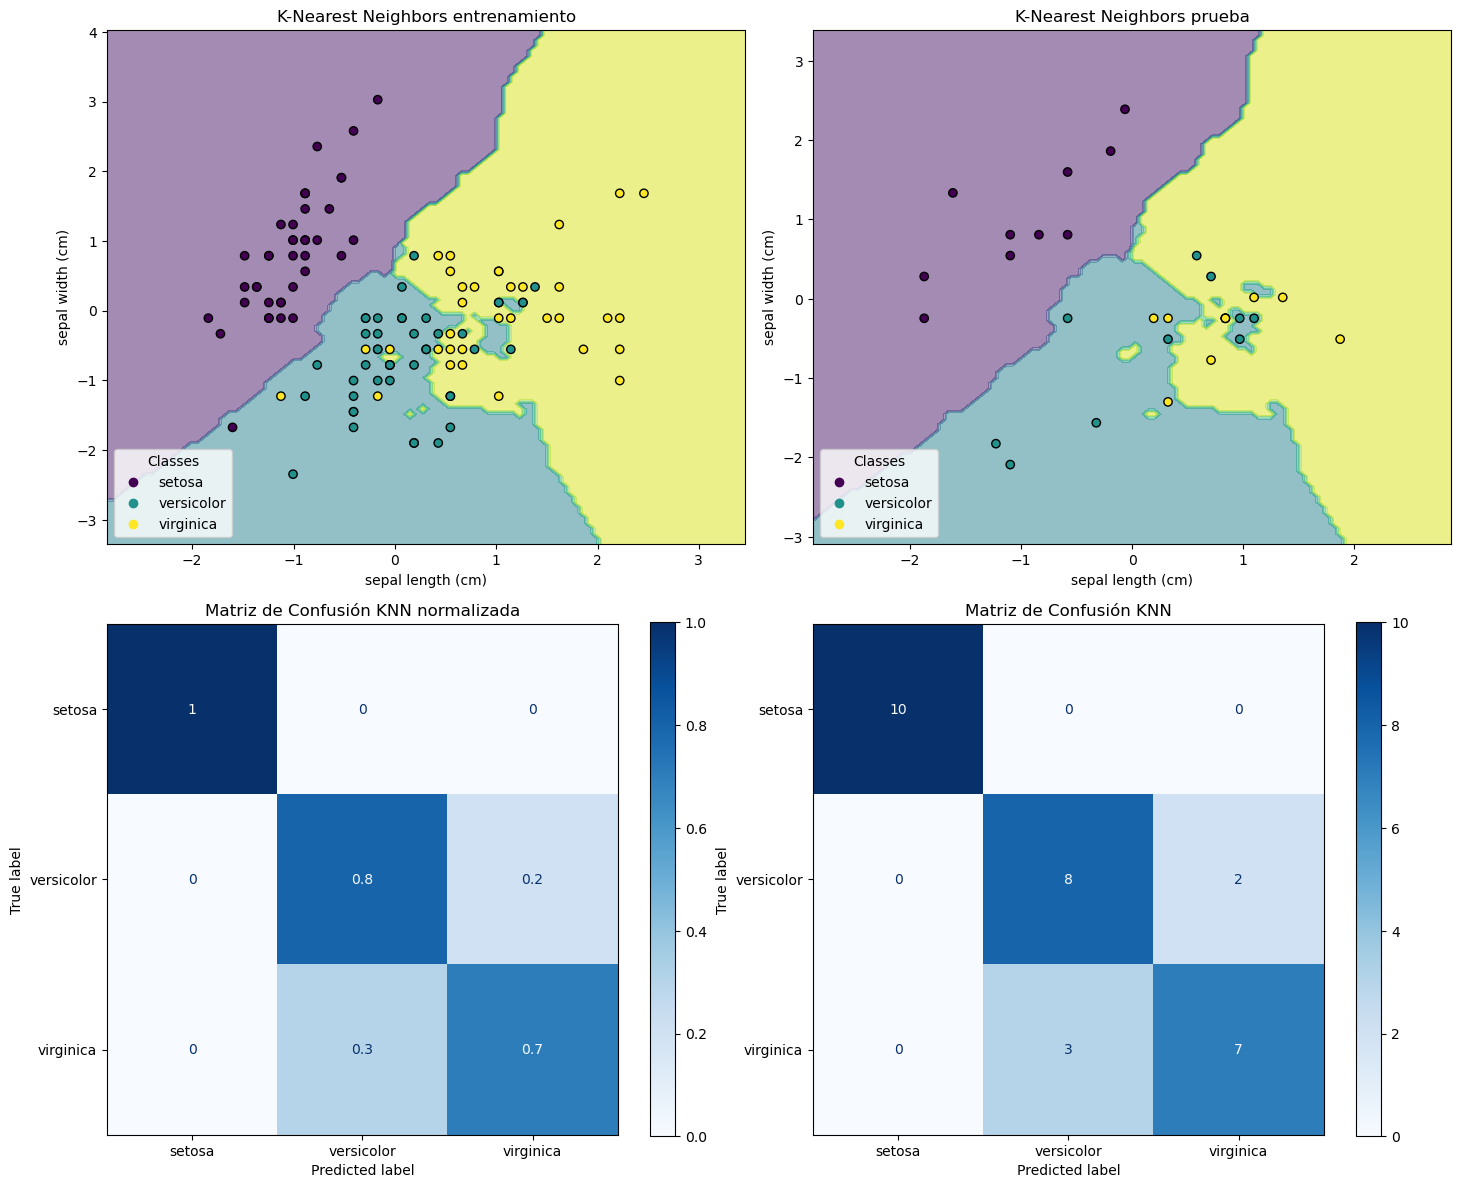

In [11]:
# Visualizar la matriz de confusión
fig,(ax)=plt.subplots(2,2,figsize=(14.5,12))
plt.subplots_adjust(wspace=0.3, hspace=0.5)

disp = DecisionBoundaryDisplay.from_estimator(
    clasificarKNN,
    X_train_escalada,
    ax=ax[0,0],
    response_method="predict",
    xlabel=iris.feature_names[0],
    ylabel=iris.feature_names[1],
    alpha=0.5,)
leyenda1=ax[0,0].scatter(X_train_escalada[:, 0], X_train_escalada[:, 1], c=y_train, edgecolor="k")
ax[0,0].legend( leyenda1.legend_elements()[0],
        iris.target_names,
        loc="lower left",
        title="Classes",)
ax[0,0].set_title("K-Nearest Neighbors entrenamiento")
##################################################
dispt = DecisionBoundaryDisplay.from_estimator(
    clasificarKNN,
    X_test_escalada,
    ax=ax[0,1],
    response_method="predict",
    xlabel=iris.feature_names[0],
    ylabel=iris.feature_names[1],
    alpha=0.5,)

leyenda2=ax[0,1].scatter(X_test_escalada[:, 0], X_test_escalada[:, 1], c=y_test, edgecolor="black")
ax[0,1].legend( leyenda2.legend_elements()[0],
        iris.target_names,
        loc="lower left",
        title="Classes",)
ax[0,1].set_title("K-Nearest Neighbors prueba")

####################################################################
classes=iris.target_names
matrixnorma=ConfusionMatrixDisplay.from_estimator(clasificarKNN, X_test_escalada, y_test, normalize='true',ax=ax[1,0], cmap='Blues',display_labels=classes)
ax[1,0].set_title("Matriz de Confusión KNN normalizada")
matrizsinno=ConfusionMatrixDisplay.from_estimator(clasificarKNN, X_test_escalada, y_test,                 ax=ax[1,1],  cmap='Blues',display_labels=classes)
ax[1,1].set_title("Matriz de Confusión KNN")

plt.tight_layout()
plt.show()

In [12]:
%%html
<style>
    .colorfondo {background-color: #D3D3D3; }
     ul {list-style-type: square; /* circle, disc, square */
         padding-left: 20px; }
     li {margin-bottom: 5px; }
</style>

<div class="colorfondo">
<h2>
<b>KNN-KNeighborsClassifier<br> </b>
</h2>

<b>Es un algoritmo simple, intuitivo y flexible, pero puede ser costoso en cómputo y sensible a la elección de parámetros y al ruido en los datos.</b>

<h2 style="color: blue;">
<b>Procedimiento</b><br>
</h2>

 <ol>
     <b><li><b>Librerias.</b></li>
        <li><b>Buscar datos. </b></li>
        <li><b>Analizar datos.</b> </li>
        <li><b>Esacalar datos.</b> </li>
        <li><b>Dividir conjuntos en entrenamiento y prueba o entrenamiento, validación y prueba.</b> </li>
        <li><b>Instanciar el modelo.</b> </li>
        <li><b>Entrenar el modelo. </b> </li>
        <li><b>Evaluar el modelo con score, accuracy_score y f1_score.</b> </li>
        <li><b>Graficar la frontera de decisión.</b> </li>
        <li><b>Visualizar la matriz de confusión.</b> </li></b>
</ol>


<p>
<b>Ventajas de KNN</b> <br><br>
<ul>      
<li><b>Simplicidad y facilidad de implementación:</b> No requiere fórmulas complejas ni entrenamiento previo; basta con medir la distancia entre puntos y seleccionar el número de vecinos, lo que lo hace muy intuitivo y fácil de interpretar.<br> </li>
<li><b>Flexibilidad:</b> Funciona tanto para problemas de clasificación como de regresión y puede manejar datos continuos y categóricos.<br> </li>
<li><b>Aprendizaje perezoso:</b> No construye un modelo explícito, lo que permite adaptarse a cambios en los datos y manejar relaciones no lineales.<br> </li>
<li><b>Sin suposiciones sobre la distribución de los datos:</b> A diferencia de otros algoritmos, no requiere que los datos sigan distribuciones normales o lineales.<br> </li>
<li><b>Interpretabilidad:</b> Los resultados se pueden explicar fácilmente observando los vecinos más cercanos y sus etiquetas.<br><br></li>
</ul>
<b>Desventajas de KNN</b><br><br>
<ul> 
<li><b>Alta complejidad computacional y de memoria:</b> Cada nueva predicción requiere calcular la distancia a todos los puntos de entrenamiento, lo que puede ser lento y costoso en conjuntos de datos grandes o de alta dimensionalidad.<br> </li>
<li><b>Sensibilidad al ruido y a valores atípicos:</b> Puntos atípicos pueden afectar significativamente la clasificación. <br></li>
<li><b>Dependencia de la elección de k y la métrica de distancia:</b> Un valor de k demasiado pequeño puede amplificar el ruido, mientras que un k demasiado grande puede incluir vecinos irrelevantes y reducir la precisión. <br></li>
<li><b>Necesidad de escalado de características:</b> Las variables deben estar en la misma escala para evitar sesgos en la medición de distancias. <br></li>
<li><b>Problemas con clases desbalanceadas:</b> Si una clase tiene muchas más muestras que otra, la predicción puede sesgarse hacia la clase mayoritaria; se puede mitigar ponderando los vecinos según su distancia. <br><br></li>
</ul>

<b>En resumen, KNN es ideal para problemas donde la interpretabilidad y la simplicidad son importantes, pero requiere cuidado en la selección de parámetros y puede ser ineficiente para grandes volúmenes de datos o conjuntos de alta dimensionalidad.</b></p>
</div>